# Data Analytics Case Study 3: Project
Bruno Sassi - NF1008627

Maria Aguilar - NF1009877

Luciana Popa - NF1005554

Tiago Ceolato – NF1006634

#Libraries

In [74]:
# Importing libraries for the GOOGL stock price prediction, using
# Multiple linear regression and Gradient boosting.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import root_mean_squared_error
from statsmodels.tsa.arima.model import ARIMA


In [75]:
# Loading and preparing the dataset:

df = pd.read_csv("alphabet_prepared.csv")
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

#EDA

In [76]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1236 entries, 0 to 1235
Data columns (total 21 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Date          1236 non-null   datetime64[ns]
 1   Price         1236 non-null   float64       
 2   Open          1236 non-null   float64       
 3   High          1236 non-null   float64       
 4   Low           1236 non-null   float64       
 5   Vol.          1236 non-null   float64       
 6   Change %      1236 non-null   float64       
 7   Return        1236 non-null   float64       
 8   MA10          1236 non-null   float64       
 9   MA20          1236 non-null   float64       
 10  MA50          1236 non-null   float64       
 11  MA200         1236 non-null   float64       
 12  Volatility20  1236 non-null   float64       
 13  Price_lag1    1236 non-null   float64       
 14  Price_lag5    1236 non-null   float64       
 15  RSI           1236 non-null   float64 

In [77]:
df.head()

,Date,Price,Open,High,Low,Vol.,Change %,Return,MA10,MA20,...,MA200,Volatility20,Price_lag1,Price_lag5,RSI,MACD,Signal,Year,Month,DayOfWeek
0,2020-08-31,81.48,82.18,82.22,81.27,26420000.0,-0.0060,-0.005978,79.925,77.4070,...,77.251429,0.011754,81.97,79.26,80.113177,1.913178,1.396334,2020,8,Monday
1,2020-09-01,82.75,81.61,82.96,81.48,22680000.0,0.0157,0.015587,80.421,77.8610,...,77.501364,0.011683,81.48,80.29,80.016247,2.026120,1.522291,2020,9,Tuesday
2,2020-09-02,85.87,83.40,86.31,83.01,49520000.0,0.0376,0.037704,81.285,78.4570,...,77.865217,0.013657,82.75,82.21,83.556150,2.340406,1.685914,2020,9,Wednesday
3,2020-09-03,81.48,84.98,85.00,80.39,63730000.0,-0.0512,-0.051124,81.552,78.7685,...,78.015833,0.018715,85.87,81.43,66.666667,2.209772,1.790686,2020,9,Thursday
4,2020-09-04,79.06,80.45,81.75,76.90,55850000.0,-0.0296,-0.029701,81.580,78.9755,...,78.057600,0.020126,81.48,81.97,57.892181,1.889191,1.810387,2020,9,Friday


In [78]:
df.isnull().sum()

Date            0
Price           0
Open            0
High            0
Low             0
Vol.            0
Change %        0
Return          0
MA10            0
MA20            0
MA50            0
MA200           0
Volatility20    0
Price_lag1      0
Price_lag5      0
RSI             0
MACD            0
Signal          0
Year            0
Month           0
DayOfWeek       0
dtype: int64

In [79]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Date,1236,2023-02-13 09:35:32.038834944,2020-08-31 00:00:00,2021-11-18 18:00:00,2023-02-13 12:00:00,2024-05-07 06:00:00,2025-08-01 00:00:00,NaN
Price,1236.0,132.223528,70.47,106.7875,132.585,155.0275,206.38,30.803291
Open,1236.0,132.170704,70.13,106.5475,132.68,155.0375,203.39,30.829658
High,1236.0,133.698786,71.9,107.95,133.77,157.19,207.05,31.054294
Low,1236.0,130.721003,70.11,105.08,130.88,152.84,202.81,30.545428
Vol.,1236.0,32255800.970874,9310000.0,23330000.0,28875000.0,36910000.0,127750000.0,13728810.644266
Change %,1236.0,0.000869,-0.0951,-0.009725,0.0014,0.0115,0.1022,0.019619
Return,1236.0,0.000869,-0.095094,-0.009721,0.001378,0.011526,0.102244,0.019618
MA10,1236.0,131.815354,72.447,106.102,132.817,155.11825,199.158,30.580493
MA20,1236.0,131.367633,73.439,105.87675,133.419,155.33525,196.6555,30.43204


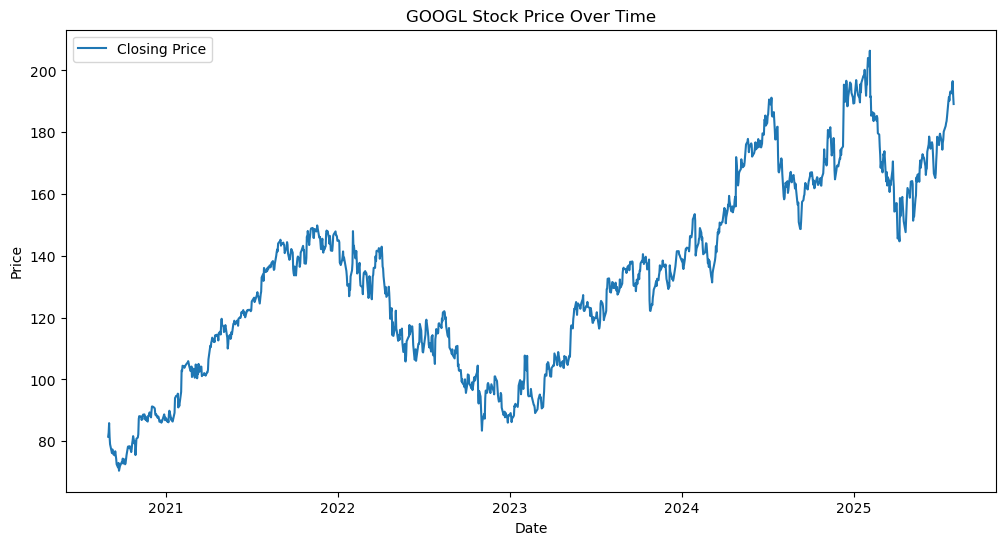

In [80]:
plt.figure(figsize=(12,6))
plt.plot(df['Date'], df['Price'], label='Closing Price')
plt.title("GOOGL Stock Price Over Time")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()

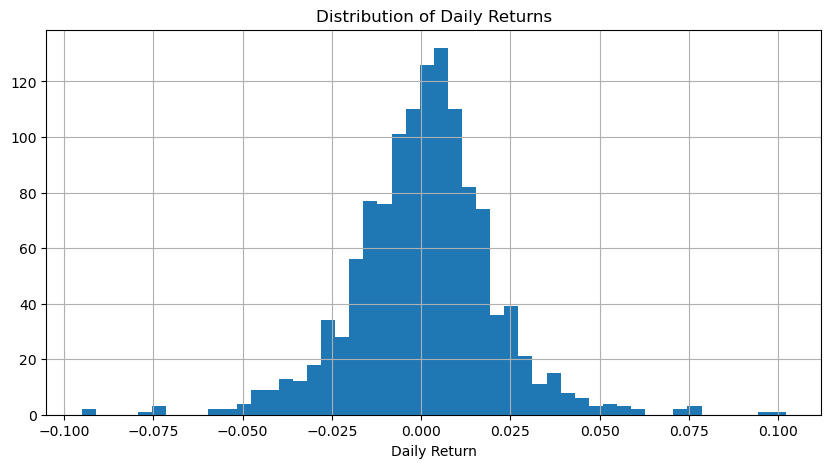

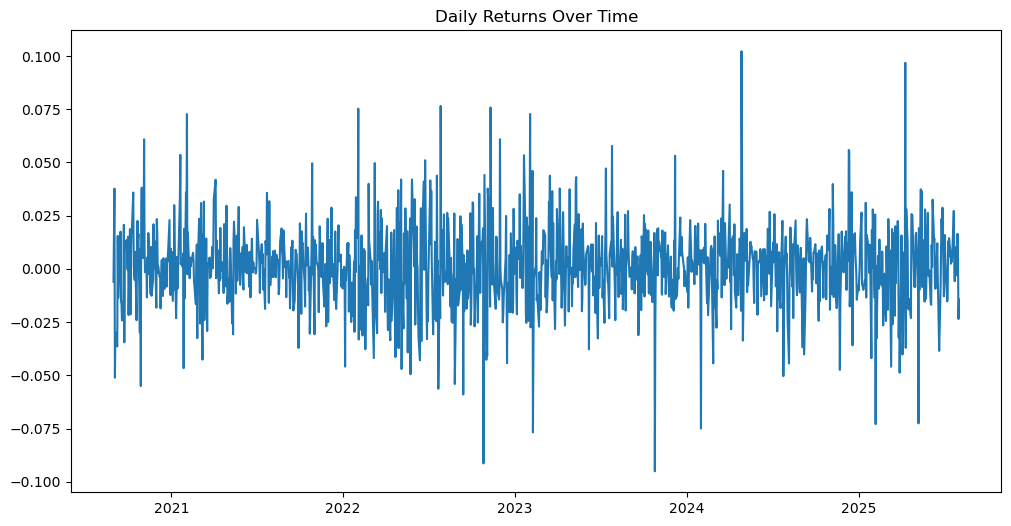

In [81]:
plt.figure(figsize=(10,5))
df['Return'].hist(bins=50)
plt.title("Distribution of Daily Returns")
plt.xlabel("Daily Return")
plt.show()

plt.figure(figsize=(12,6))
plt.plot(df['Date'], df['Return'], label='Daily Return')
plt.title("Daily Returns Over Time")
plt.show()


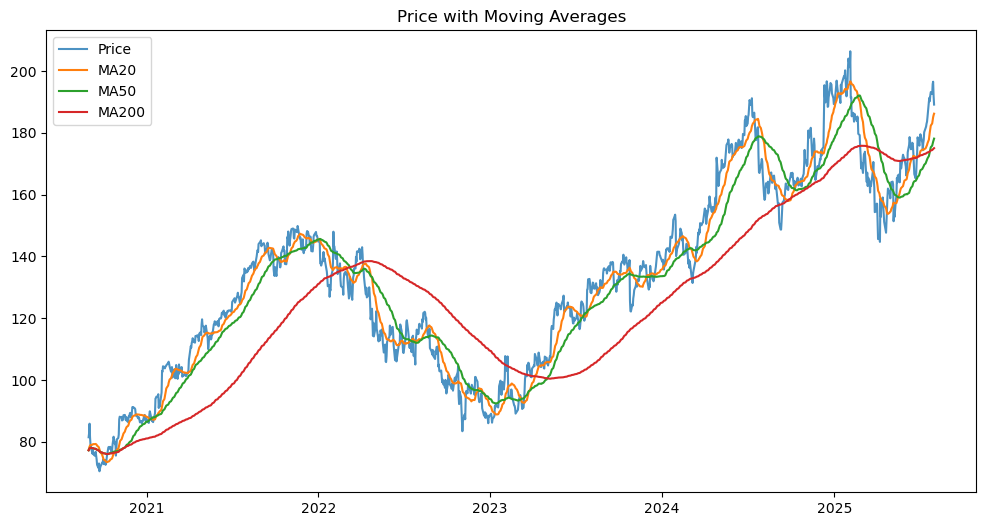

In [82]:
plt.figure(figsize=(12,6))
plt.plot(df['Date'], df['Price'], label='Price', alpha=0.8)
plt.plot(df['Date'], df['MA20'], label='MA20')
plt.plot(df['Date'], df['MA50'], label='MA50')
plt.plot(df['Date'], df['MA200'], label='MA200')
plt.title("Price with Moving Averages")
plt.legend()
plt.show()

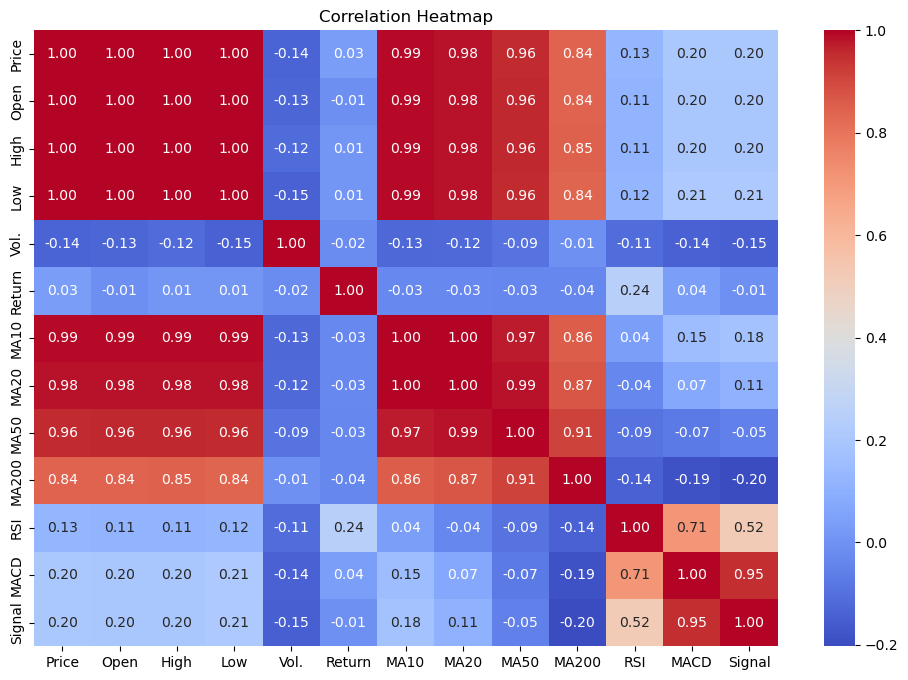

In [83]:
plt.figure(figsize=(12,8))
corr = df[['Price','Open','High','Low','Vol.','Return','MA10','MA20','MA50','MA200','RSI','MACD','Signal']].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


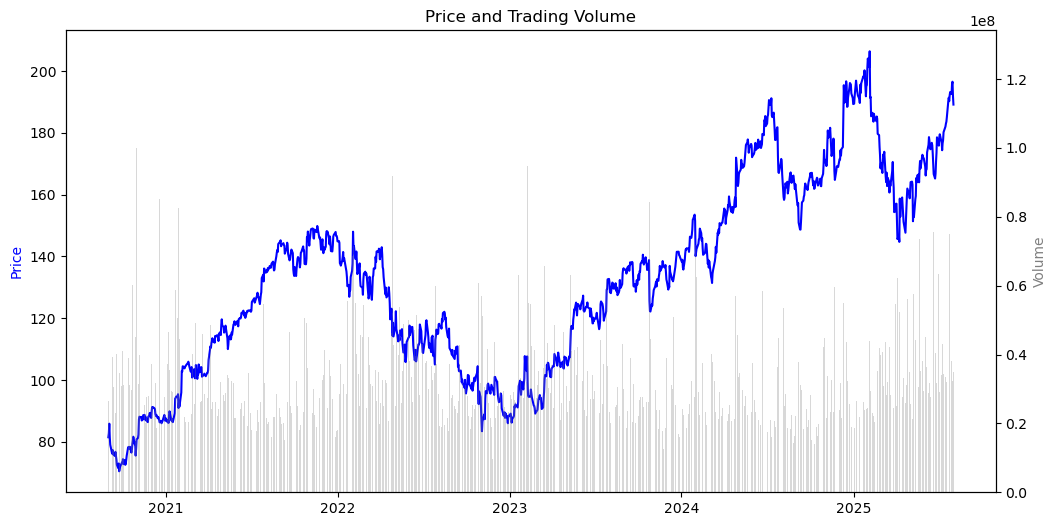

In [84]:
fig, ax1 = plt.subplots(figsize=(12,6))

ax1.plot(df['Date'], df['Price'], color='blue', label='Price')
ax1.set_ylabel("Price", color="blue")
ax2 = ax1.twinx()
ax2.bar(df['Date'], df['Vol.'], alpha=0.3, color='gray', label='Volume')
ax2.set_ylabel("Volume", color="gray")

plt.title("Price and Trading Volume")
plt.show()

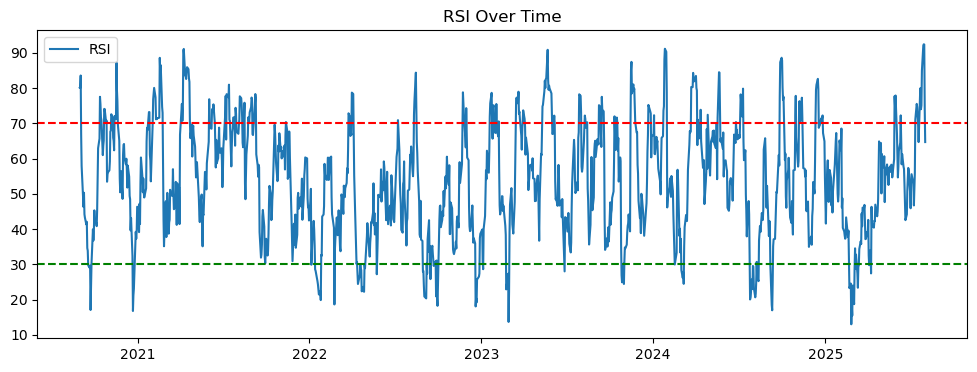

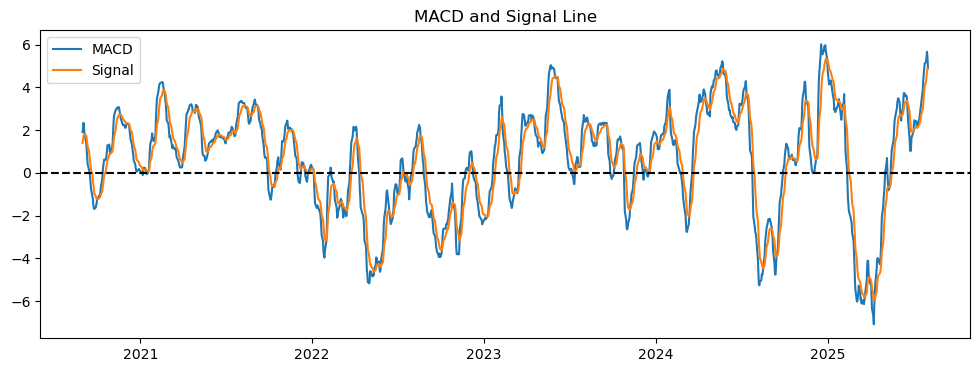

In [85]:
plt.figure(figsize=(12,4))
plt.plot(df['Date'], df['RSI'], label='RSI')
plt.axhline(70, color='red', linestyle='--')
plt.axhline(30, color='green', linestyle='--')
plt.title("RSI Over Time")
plt.legend()
plt.show()

plt.figure(figsize=(12,4))
plt.plot(df['Date'], df['MACD'], label='MACD')
plt.plot(df['Date'], df['Signal'], label='Signal')
plt.axhline(0, color='black', linestyle='--')
plt.title("MACD and Signal Line")
plt.legend()
plt.show()


#Testing

Creating the target variable (which is the next-day closing price)


In [86]:
df['y_next'] = df['Price'].shift(-1)

In [87]:
# Selecting features for H1, including lagged prices only:

features_A = ['Price_lag1', 'Price_lag5']

# Selecting features for H2 and H3, which are the lagged proces and the technical indicators:

features_B = features_A + [
    'MA10','MA20','MA50','MA200',
    'RSI','MACD','Signal','Volatility20','Vol.'
]

# The MovingAvg_10day is the short-term average, the MovingAvg_20day is the medium-term average.
# MovingAvg_50day is a medium/long-term average, and MovingAvg_200day is a long-term average.


In [88]:
# Dropping rows with missing/null values:

df = df.dropna(subset=features_B + ['y_next'])

X_A = df[features_A]   # for model A
X_B = df[features_B]   # for model B and gradient booting
y = df['y_next']     # target (next day closing price)
dates = df['Date']

In [89]:
# Separating data chronologically:

train_idx = dates < "2024-01-01"   # our training data (2021-2023)
valid_idx = (dates >= "2024-01-01") & (dates < "2025-01-01") # just a validation data (2024)
test_idx  = dates >= "2025-01-01"   # our testing data (2025)

Calculating evaluation metrics:

In [90]:
def evaluate_model(name, y_true, y_pred):
    return {
        "Model": name,
        "RMSE": root_mean_squared_error(y_true, y_pred),  # this will be our avg predictor error
        "MAE": mean_absolute_error(y_true, y_pred),    # error in monetary value
        "R2": r2_score(y_true, y_pred)    # % of the variance explained
    }

results = []

**Multiple Linear Regression**

In [91]:
# Model A (H1):

pipe_lr_A = Pipeline([
    ("scaler", StandardScaler()),      # normalizing data so we can compare them properly
    ("lr", LinearRegression())
])
pipe_lr_A.fit(X_A[train_idx], y[train_idx])
results.append(evaluate_model("LR_A (lags) - Valid", y[valid_idx], pipe_lr_A.predict(X_A[valid_idx])))
results.append(evaluate_model("LR_A (lags) - Test",  y[test_idx],  pipe_lr_A.predict(X_A[test_idx])))

In [92]:
# Model B (H2):

pipe_lr_B = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LinearRegression())
])
pipe_lr_B.fit(X_B[train_idx], y[train_idx])
results.append(evaluate_model("LR_B (lags+tech) - Valid", y[valid_idx], pipe_lr_B.predict(X_B[valid_idx])))
results.append(evaluate_model("LR_B (lags+tech) - Test",  y[test_idx],  pipe_lr_B.predict(X_B[test_idx])))

In [93]:
# Most relevant coefficients obtained from Model B:

coef_B = pd.Series(pipe_lr_B.named_steps['lr'].coef_, index=features_B).sort_values(key=abs, ascending=False)
print("\nTop 10 Linear Regression Coefficients (Model B):")
print(coef_B.head(10))


Top 10 Linear Regression Coefficients (Model B):
MA20          33.319387
Signal       -14.513219
MACD          14.146572
MA50         -11.955598
MA10           9.149862
Price_lag1    -7.194964
Price_lag5    -2.658615
MA200         -1.380593
RSI            1.092320
Vol.           0.099249
dtype: float64


With the previous output we have the expected change
in the target variable (next day closing price)
when there is a increase of 1 unit on the predictor, while keeping other variables constant.
MA20 shows that for every 1 unit increase in the 20 day moving avg, the predicted target will increase by 27.97 units.
Signal shows that for every 1 unit increase in signal, the predictor will decrease by 13.99 units.
We can see that the most influential coefficients are MA20, Signal and also MACD, which are larger compared to the others.

**Machine Learning**

**Gradient Boosting**

In [94]:
# Model C (H3):

gb = GradientBoostingRegressor(random_state=42)

# Adjusting the parameters:

param_grid = {
    "n_estimators": [200, 400],    # number of trees
    "max_depth": [2, 3],
    "learning_rate": [0.05, 0.1]
}


grid = GridSearchCV(
    gb,
    param_grid,
    cv=[(train_idx, valid_idx)],  # train/valid split
    scoring="neg_root_mean_squared_error"
)
grid.fit(X_B, y)

# Best gradient boosting model:

best_gb = grid.best_estimator_
results.append(evaluate_model("GB - Valid", y[valid_idx], best_gb.predict(X_B[valid_idx])))
results.append(evaluate_model("GB - Test",  y[test_idx],  best_gb.predict(X_B[test_idx])))

In [95]:
# Showing feature importances from the gradient boosting model:

gb_importance = pd.Series(best_gb.feature_importances_, index=features_B).sort_values(ascending=False)
print("\nTop 10 Gradient Boosting Feature Importances:")
print(gb_importance.head(10))


Top 10 Gradient Boosting Feature Importances:
Price_lag1    0.841634
MA10          0.139529
MA20          0.009869
Price_lag5    0.004047
RSI           0.002039
MA200         0.001288
MA50          0.000862
Vol.          0.000426
Signal        0.000180
MACD          0.000069
dtype: float64


The previuos output shows how much each feature contributes to reducing error in the ensemble trees.
Price_lag1 is the main feature, with 85.85% importance.
 It indicates that the previous day price (Price_lag1) is the most predictive feature in this model.
When analysing data with this model we can get the dominant feature, even if the linear coefficient was smaller, for example.

**ARIMA**

In [ ]:
# Univariate series (price) indexed by Date
series = df.set_index("Date")["Price"].sort_index()

# Date partitions (exactly as LR/GB)
train_end = df.loc[train_idx, "Date"].max()
valid_dates = df.loc[valid_idx, "Date"].sort_values().tolist()
test_dates  = df.loc[test_idx,  "Date"].sort_values().tolist()

# --- Choose a small ARIMA order using Train only (fast AIC scan)
cand = [(1,1,0),(1,1,1),(2,1,1),(5,1,0)]
best_order, best_aic = None, np.inf
train_series = series.loc[:train_end]
for order in cand:
    try:
        res = ARIMA(train_series, order=order).fit()
        if res.aic < best_aic:
            best_order, best_aic = order, res.aic
    except Exception:
        pass
if best_order is None:
    best_order = (1,1,1)
print(f"[ARIMA] Using order {best_order} (AIC≈{best_aic:.2f})")

# --- One-step-ahead forecast of y_next for a list of 'anchor' dates t
# For each date t, fit ARIMA on history up to t, then forecast 1 step (t+1).
def arima_nextday(series, anchor_dates, order):
    preds = []
    for t in anchor_dates:
        hist = series.loc[:t]
        res = ARIMA(hist, order=order).fit()
        preds.append(res.forecast(1).iloc[0])  # next observed point after t
    return pd.Series(preds, index=pd.to_datetime(anchor_dates))

# Forecast VALID and TEST
arima_valid_pred = arima_nextday(series, valid_dates, best_order)
arima_test_pred  = arima_nextday(series, test_dates,  best_order)

# Ground truth for y_next (your target) over the same rows
y_valid_true = y.loc[valid_idx]  # y_next for 2024 rows
y_test_true  = y.loc[test_idx]   # y_next for 2025 rows

# Metrics helper
def _eval(y_true, y_pred):
    y_true = pd.Series(y_true.values, index=y_pred.index)  # align
    rmse = float(np.sqrt(((y_true - y_pred)**2).mean()))
    mae  = float((y_true - y_pred).abs().mean())
    ss_res = ((y_true - y_pred)**2).sum()
    ss_tot = ((y_true - y_true.mean())**2).sum()
    r2 = float(1 - ss_res/ss_tot) if ss_tot > 0 else np.nan
    return rmse, mae, r2

rmse_v, mae_v, r2_v = _eval(y_valid_true, arima_valid_pred)
rmse_t, mae_t, r2_t = _eval(y_test_true,  arima_test_pred)

results.append({"Model":"ARIMA - Valid","RMSE":rmse_v,"MAE":mae_v,"R2":r2_v})
results.append({"Model":"ARIMA - Test", "RMSE":rmse_t,"MAE":mae_t,"R2":r2_t})

print(f"ARIMA {best_order} - Valid: RMSE={rmse_v:.3f} MAE={mae_v:.3f} R2={r2_v:.3f}")
print(f"ARIMA {best_order} - Test : RMSE={rmse_t:.3f} MAE={mae_t:.3f} R2={r2_t:.3f}")

c:\Users\bruno\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\bruno\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\bruno\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\bruno\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(d

[ARIMA] Using order (1, 1, 1) (AIC≈3732.99)


c:\Users\bruno\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\bruno\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
c:\Users\bruno\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\bruno\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(da

ARIMA (1, 1, 1) - Valid: RMSE=2.915 MAE=2.097 R2=0.964
ARIMA (1, 1, 1) - Test : RMSE=3.650 MAE=2.768 R2=0.937


c:\Users\bruno\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\bruno\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


# Testing Visualization

In [97]:
# Final results table:

results_df = pd.DataFrame(results)
print("\nModel Evaluation Results:")
results_df


Model Evaluation Results:


,Model,RMSE,MAE,R2
0,LR_A (lags) - Valid,4.269505,3.245586,0.922672
1,LR_A (lags) - Test,4.854343,3.946325,0.888615
2,LR_B (lags+tech) - Valid,3.617857,2.751141,0.944476
3,LR_B (lags+tech) - Test,4.871165,3.955049,0.887841
4,GB - Valid,3.162111,2.392778,0.957583
5,GB - Test,3.040981,2.378138,0.956289
6,ARIMA - Valid,2.915371,2.096514,0.963945
7,ARIMA - Test,3.649649,2.767884,0.937039


In general, there is a great proportion of variance being explained, as showed by the high R2s.
By adding technical indicators on LR_B the performance increased a bit, but decreased RMSE as well.
The opposite happened to the test performance. Can indicate overfitting.
The gradient boosting model performs better than the previous models, with less errors and higher R2s.
In the end, the gradient boosting test seems to be more robust, capturing the nonlinear patterns that the LR may miss.

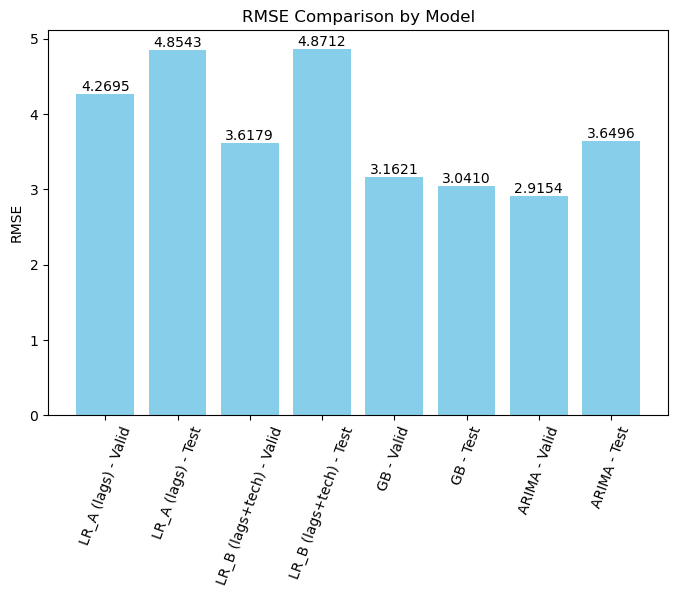

In [118]:
plt.figure(figsize=(8,5))
bars = plt.bar(results_df["Model"], results_df["RMSE"], color="skyblue")
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,   # x-position (center of the bar)
        height,                            # y-position (top of the bar)
        f"{height:.4f}",                   # label text (2 decimal places)
        ha="center", va="bottom"           # center align horizontally, place above bar
    )
plt.xticks(rotation=70)
plt.title("RMSE Comparison by Model")
plt.ylabel("RMSE")
plt.show()

Gradient Boosting (GB) has the lowest RMSE in both validation and test

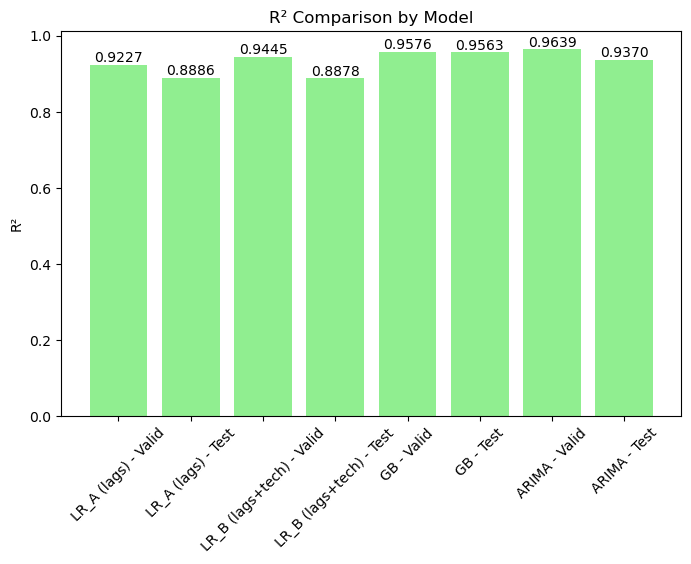

In [112]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
bars = plt.bar(results_df["Model"], results_df["R2"], color="lightgreen")
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,   # x-position (center of the bar)
        height,                            # y-position (top of the bar)
        f"{height:.4f}",                   # label text (2 decimal places)
        ha="center", va="bottom"           # center align horizontally, place above bar
    )
plt.xticks(rotation=45)
plt.title("R² Comparison by Model")
plt.ylabel("R²")
plt.show()


GB achieves R² ≈ 0.97+, higher than both linear regressions. This confirms GB generalizes best.

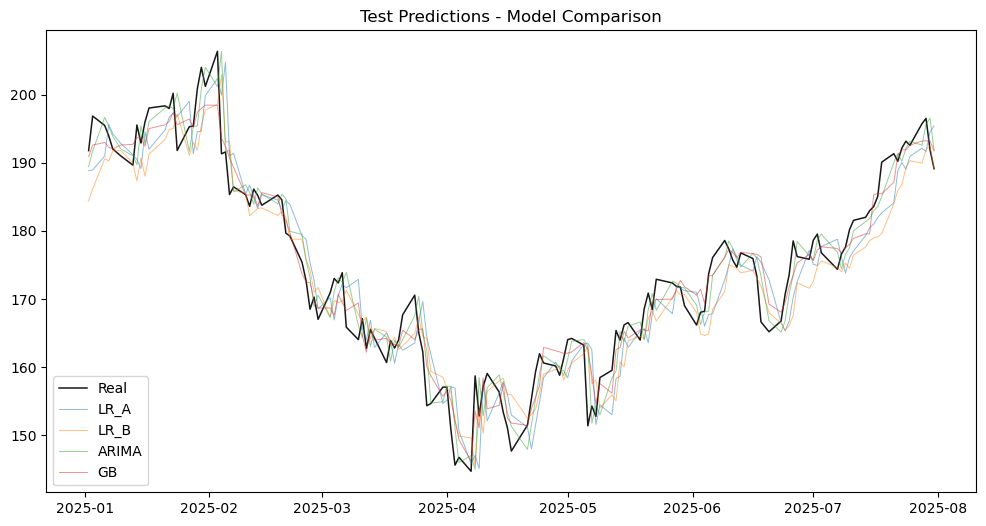

In [126]:
plt.figure(figsize=(12,6))
plt.plot(dates[test_idx], y[test_idx], label="Real", lw=1.1, alpha=0.9, color="black")
plt.plot(dates[test_idx], pipe_lr_A.predict(X_A[test_idx]), label="LR_A", lw=0.7, alpha=0.5)
plt.plot(dates[test_idx], pipe_lr_B.predict(X_B[test_idx]), label="LR_B", lw=0.7, alpha=0.5)
plt.plot(dates[test_idx], arima_test_pred, label="ARIMA", lw=0.7, alpha=0.5)
plt.plot(dates[test_idx], best_gb.predict(X_B[test_idx]), label="GB", lw=0.7,  alpha=0.5)
plt.title("Test Predictions - Model Comparison")
plt.legend()
plt.show()


In [101]:
# H1: R² ≥ 0.70 for lag-only model (Test)
r2_h1 = results_df.loc[results_df.Model=="LR_A (lags) - Test","R2"].iloc[0]
print("H1:", "✅ PASS" if r2_h1 >= 0.70 else "❌ FAIL", f"(Test R²={r2_h1:.4f})")


H1: ✅ PASS (Test R²=0.8886)


In [102]:
# H2: ≥5% RMSE reduction when adding tech indicators (Model B vs A)
rmse_A_v = results_df.loc[results_df.Model=="LR_A (lags) - Valid","RMSE"].iloc[0]
rmse_B_v = results_df.loc[results_df.Model=="LR_B (lags+tech) - Valid","RMSE"].iloc[0]
rmse_A_t = results_df.loc[results_df.Model=="LR_A (lags) - Test","RMSE"].iloc[0]
rmse_B_t = results_df.loc[results_df.Model=="LR_B (lags+tech) - Test","RMSE"].iloc[0]
imp_v = (rmse_A_v - rmse_B_v) / rmse_A_v * 100
imp_t = (rmse_A_t - rmse_B_t) / rmse_A_t * 100
print(f"H2: Valid +{imp_v:.2f}%  |  Test {imp_t:+.2f}%  ->", "✅ PASS on Valid, ❌ FAIL on Test" if imp_t < 5 else "✅ PASS")


H2: Valid +15.26%  |  Test -0.35%  -> ✅ PASS on Valid, ❌ FAIL on Test


In [103]:
# H3: GB beats ARIMA on Test
rmse_gb_t = results_df.loc[results_df.Model=="GB - Test","RMSE"].iloc[0]
rmse_ar_t = results_df.loc[results_df.Model=="ARIMA - Test","RMSE"].iloc[0]
print("H3:", "✅ PASS" if rmse_gb_t < rmse_ar_t else "❌ FAIL",
      f"(GB={rmse_gb_t:.4f}, ARIMA={rmse_ar_t:.4f}, Δ={(rmse_ar_t - rmse_gb_t)/rmse_ar_t*100:.2f}% lower)")

H3: ✅ PASS (GB=3.0410, ARIMA=3.6496, Δ=16.68% lower)


**Model Interpretetion using Gradient Boosting**

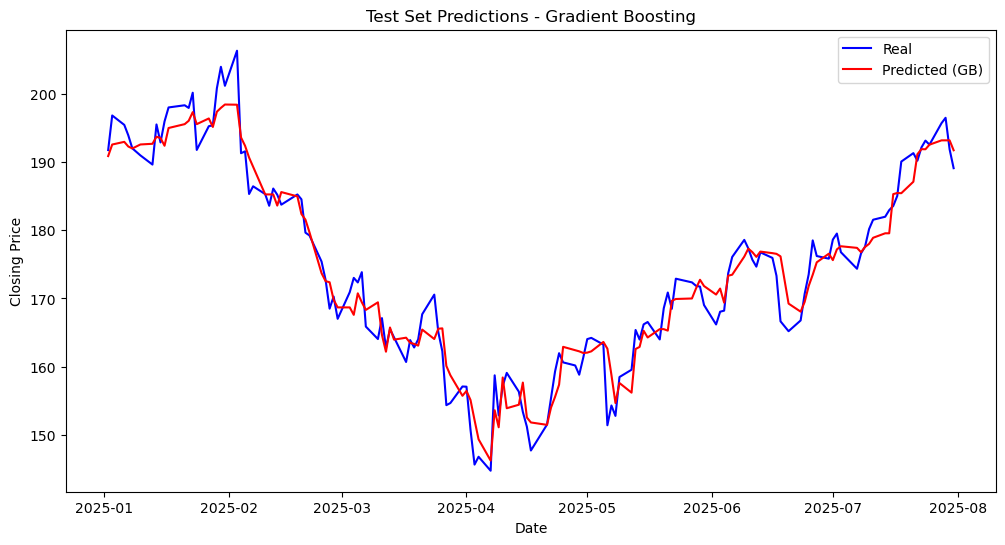

In [104]:
y_test_true = y[test_idx]
y_test_pred_gb = best_gb.predict(X_B[test_idx])

plt.figure(figsize=(12,6))
plt.plot(dates[test_idx], y_test_true, label="Real", color="blue")
plt.plot(dates[test_idx], y_test_pred_gb, label="Predicted (GB)", color="red")
plt.title("Test Set Predictions - Gradient Boosting")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.legend()
plt.show()

Lines overlap closely → GB tracks the overall trend (ups, downs, reversals) very well.

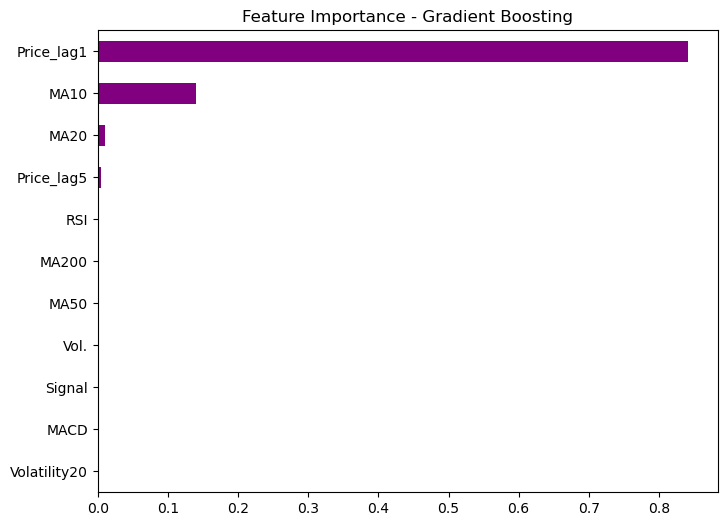

In [105]:
gb_importance = pd.Series(best_gb.feature_importances_, index=features_B).sort_values(ascending=True)

plt.figure(figsize=(8,6))
gb_importance.plot(kind="barh", color="purple")
plt.title("Feature Importance - Gradient Boosting")
plt.show()

Price_lag1 dominates → yesterday’s price is the strongest predictor.

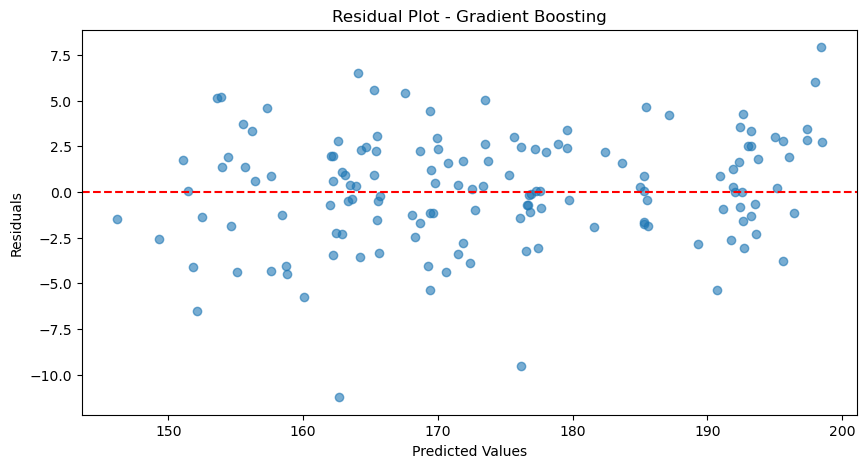

In [106]:
residuals = y_test_true - y_test_pred_gb

plt.figure(figsize=(10,5))
plt.scatter(y_test_pred_gb, residuals, alpha=0.6)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot - Gradient Boosting")
plt.show()

Residuals are spread around 0 (red line) without strong patterns.
This suggests GB is not systematically biased (no consistent over/underestimation).
Some larger residuals exist (outliers), but mostly errors are small.

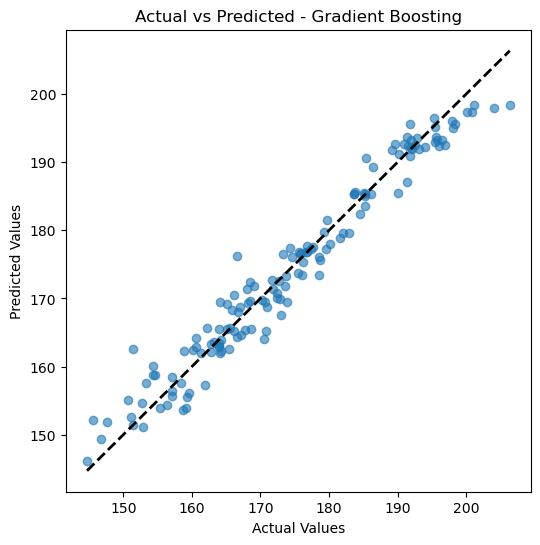

In [107]:
plt.figure(figsize=(6,6))
plt.scatter(y_test_true, y_test_pred_gb, alpha=0.6)
plt.plot([y_test_true.min(), y_test_true.max()],
         [y_test_true.min(), y_test_true.max()],
         'k--', lw=2)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted - Gradient Boosting")
plt.show()

Points align almost perfectly along the 45° dashed line. Indicates very high predictive accuracy